In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import sys
path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(splitted[0]+os.sep, splitted[1], splitted[2], splitted[3])
src_path = os.path.join(user_independent, 'GitHub', 'Photoswitching')
sys.path.append(src_path)

import src.miscellaneous as mi
import src.figure as fi
import src.blinking as bl
import experimental_data_analysis as eda

%load_ext autoreload
%autoreload 2

In [3]:
exp_data = eda.ExperimentalData(file=r"C:\Users\ebert\Desktop\Fluorocubes_AF647_widefield_dSTORM\Fluorocubes_1x(0)_kontrolle\1x(0)xAF647_5ms_120kfr_Epi_EMCCD_crop_f7,5_400mw_256x256px_quad_line-PFS_1.txt")
exp_data.data

,x_position,x_uncertain,y_position,y_uncertain,frame,intensity,fit,background
0,19347.50,25,22437.000,25,0,11736.20,1021590.0,625.343
1,6807.95,25,22979.400,25,0,9243.22,869105.0,631.770
2,24813.80,25,21359.400,25,0,10450.10,1159410.0,639.918
3,16650.40,25,278.715,25,0,8321.14,860542.0,624.265
4,10181.00,25,25229.600,25,0,5022.90,533402.0,592.715
...,...,...,...,...,...,...,...,...
40543,27465.70,25,25982.900,25,119926,2968.89,620746.0,596.517
40544,27715.30,25,25933.000,25,119927,1533.61,488657.0,590.035
40545,11352.90,25,25690.200,25,119937,2174.08,460481.0,583.781
40546,11400.10,25,25733.800,25,119938,4764.45,674141.0,585.126


In [5]:
exp_data.cluster(eps=20, min_samples=3)

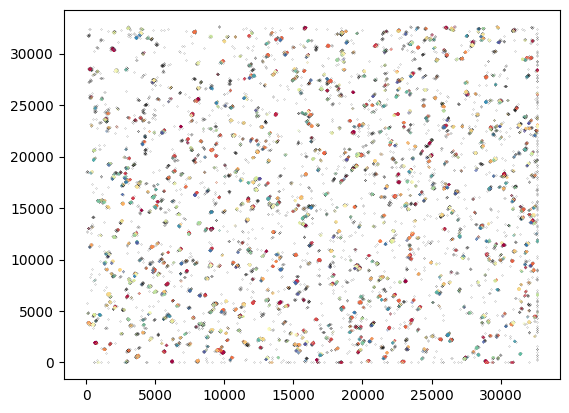

In [8]:
exp_data.plot()

In [9]:
groups = exp_data.data.groupby('cluster_id')

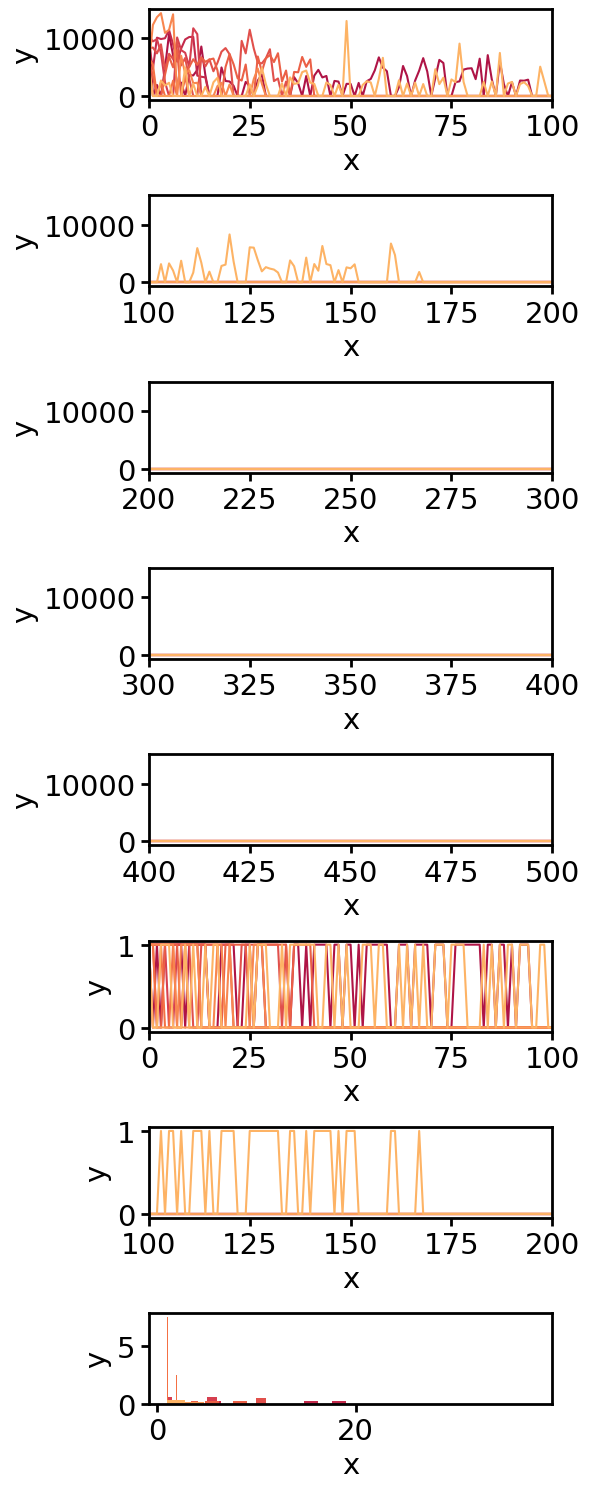

In [10]:
axes = fi.universal_figure(nrows=8, fig_height=15)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, 30)]
for i, (group, color) in enumerate(zip(groups, colors)):
    event_series = pd.Series(np.zeros(119928))
    on_off_series = pd.Series(np.zeros(119928))
    if not group[0] == -1:
        if i < 10:
            event_series.values[group[1]['frame']] = group[1]['intensity']
            on_off_series.values[group[1]['frame']] = 1
            fi.universal_figure(axes=axes[0], type_='line', data=[event_series.index, event_series.values], color=color, xlim=[0, 100])
            fi.universal_figure(axes=axes[1], type_='line', data=[event_series.index, event_series.values], color=color, xlim=[100, 200])
            fi.universal_figure(axes=axes[2], type_='line', data=[event_series.index, event_series.values], color=color, xlim=[200, 300])
            fi.universal_figure(axes=axes[3], type_='line', data=[event_series.index, event_series.values], color=color, xlim=[300, 400])
            fi.universal_figure(axes=axes[4], type_='line', data=[event_series.index, event_series.values], color=color, xlim=[400, 500])
            fi.universal_figure(axes=axes[5], type_='line', data=[on_off_series.index, on_off_series.values], color=color, xlim=[0, 100])
            fi.universal_figure(axes=axes[6], type_='line', data=[on_off_series.index, on_off_series.values], color=color, xlim=[100, 200])
            on_periods, off_periods, on_frames, off_frames = bl.get_blinking_statistics(event_series)
            fi.universal_figure(axes=axes[7], type_='hist', data=on_periods, color=color, density=True)
fig = mi.get_figure(axes)
fig.tight_layout()
        

In [11]:
on_periods, off_periods, on_frames, off_frames = bl.get_blinking_statistics(event_series)
on_off_frames, on_off_values = bl.get_analytical_off_statistics(off_frames, off_periods)

IndexError: index -1 is out of bounds for axis 0 with size 0

(0.0, 100.0)

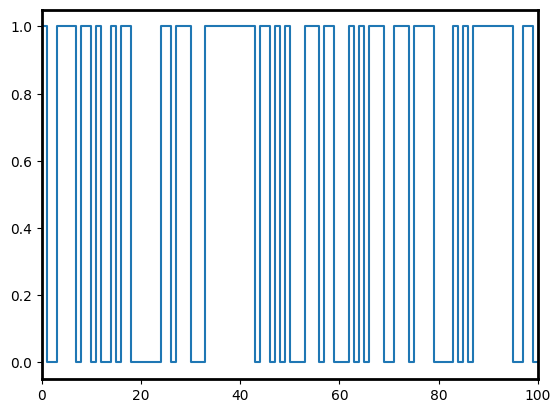

In [34]:
plt.plot(on_off, values)
plt.xlim(0, 100)